Task 1 -- Exploring and Visualizing a Simple Dataset

In [ ]:
import pandas as pd

In [58]:
df = pd.read_csv('D:\Internship\Task No 1\Datasets/iris.csv')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [59]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [60]:
df.shape

(150, 5)

In [61]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

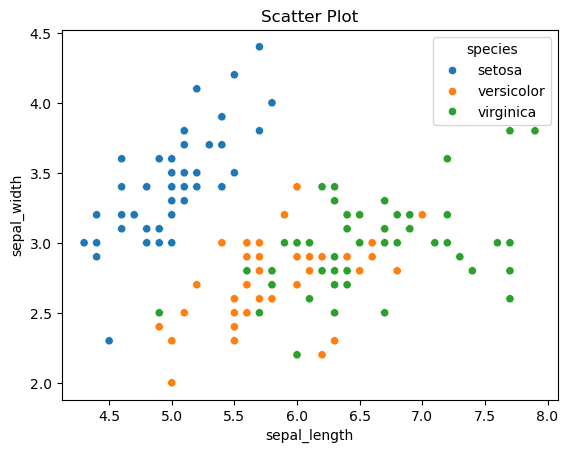

In [63]:
sns.scatterplot(x = 'sepal_length', y = 'sepal_width', hue = 'species', data=df)
plt.title('Scatter Plot')
plt.savefig('D:\Internship\Task No 1\images\Task 1 img/scatter_plot.png')

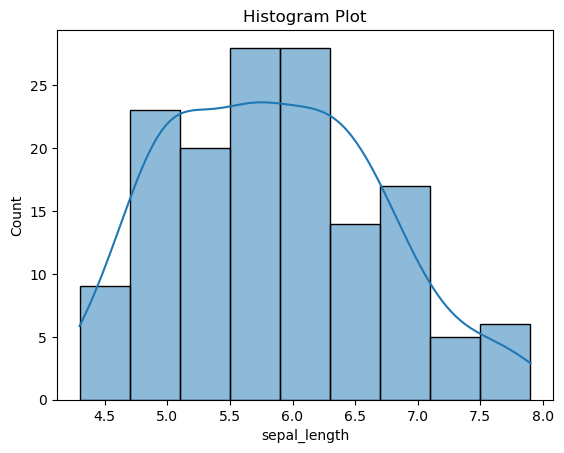

In [64]:
sns.histplot(df['sepal_length'], kde=True)
plt.title('Histogram Plot')
plt.savefig('D:\Internship\Task No 1\images\Task 1 img/histogram_plot.png')

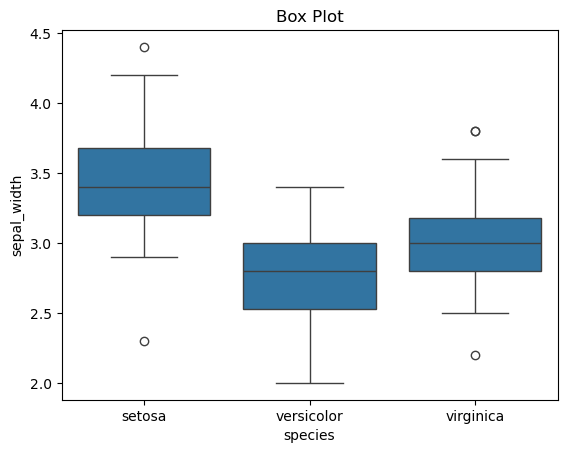

In [65]:
sns.boxplot(x = 'species', y = 'sepal_width',data=df)
plt.title('Box Plot')
plt.savefig('D:\Internship\Task No 1\images\Task 1 img/box_plot.png')

TASK 2 — Credit Risk Prediction

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [67]:
df2 = pd.read_csv("D:\Internship\Task No 1\Datasets/train.csv")
df2.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [68]:
df2.shape

(614, 13)

In [69]:
df2.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [70]:
df2['LoanAmount'] = df2['LoanAmount'].fillna(df2['LoanAmount'].mean())

df2['Gender'] = df2['Gender'].fillna(df2['Gender'].mode()[0])

df2['Married'] = df2['Married'].fillna(df2['Married'].mode()[0])

df2['Dependents'] = df2['Dependents'].fillna(df2['Dependents'].mode()[0])

df2['Self_Employed'] = df2['Self_Employed'].fillna(df2['Self_Employed'].mode()[0])

df2['Loan_Amount_Term'] = df2['Loan_Amount_Term'].fillna(df2['Loan_Amount_Term'].mode()[0])

df2['Credit_History'] = df2['Credit_History'].fillna(df2['Credit_History'].mode()[0])

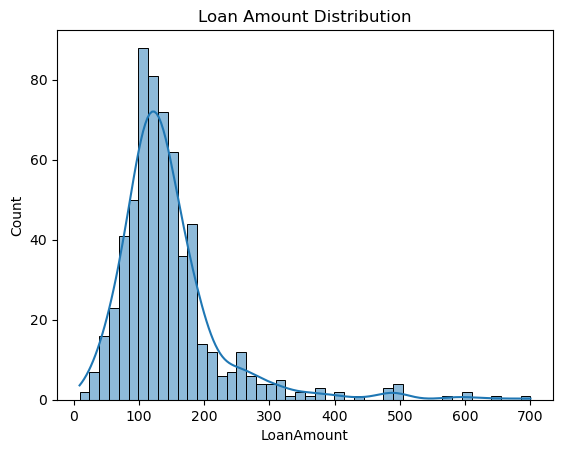

In [71]:
sns.histplot(df2['LoanAmount'], kde=True)

plt.title("Loan Amount Distribution")
plt.savefig('D:\Internship\Task No 1\images\Task 2 img/loan_amount_distribution.png')

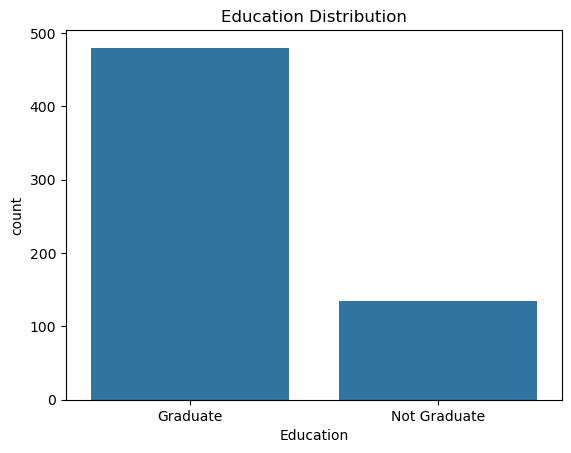

In [72]:
sns.countplot(x='Education', data=df2)

plt.title("Education Distribution")
plt.savefig('D:\Internship\Task No 1\images\Task 2 img/education_distribution.png')

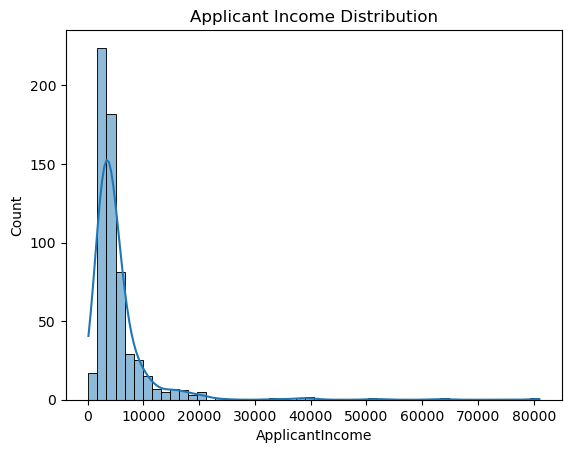

In [73]:
sns.histplot(df2['ApplicantIncome'], kde=True)

plt.title("Applicant Income Distribution")

plt.savefig('D:\Internship\Task No 1\images\Task 2 img/applicant_income_distribution.png')

In [74]:
le = LabelEncoder()

for column in df2.columns:
    if df2[column].dtype == 'object':
        df2[column] = le.fit_transform(df2[column])       

In [75]:
X = df2.drop('Loan_Status', axis=1)

y = df2['Loan_Status']

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [77]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
y_pred = model.predict(X_test)

In [79]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617


In [80]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18 25]
 [ 1 79]]


Text(50.722222222222214, 0.5, 'Actual')

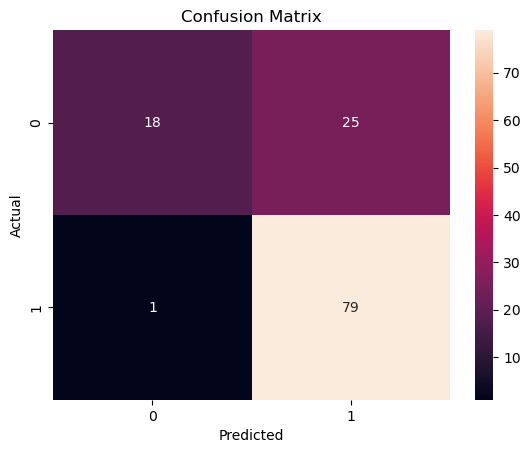

In [82]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")



Task 4 -- Predicting Insurance Claim Amounts

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

In [83]:
df = pd.read_csv("D:\Internship\Task No 1\Datasets/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [84]:
df.shape

(1338, 7)

In [85]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [86]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])

df['smoker'] = le.fit_transform(df['smoker'])

df['region'] = le.fit_transform(df['region'])

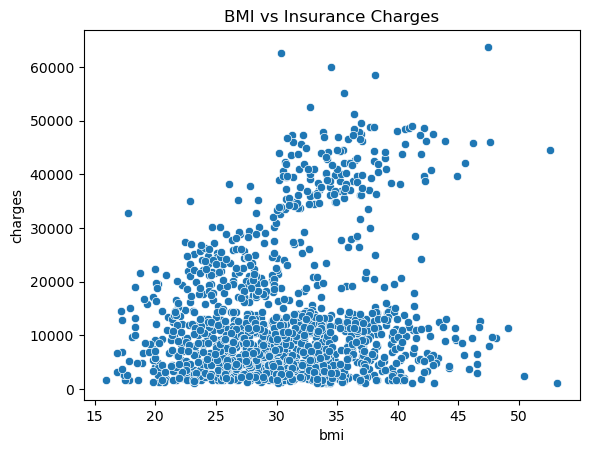

In [88]:
sns.scatterplot(x='bmi', y='charges', data=df)

plt.title("BMI vs Insurance Charges")

plt.savefig('D:\Internship\Task No 1\images\Task 4 img/BMI_vs_Insurance.png')

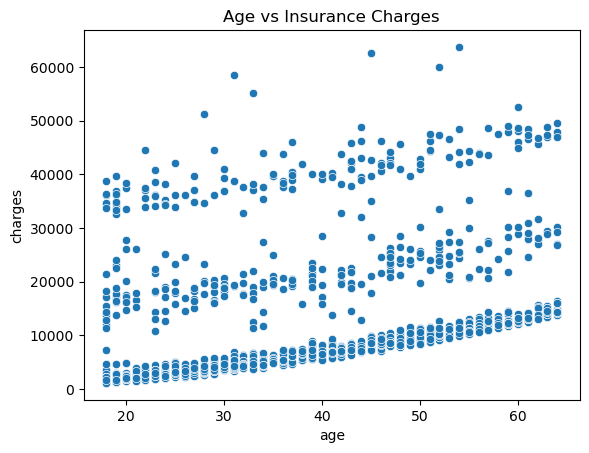

In [89]:
sns.scatterplot(x='age', y='charges', data=df)

plt.title("Age vs Insurance Charges")

plt.savefig('D:\Internship\Task No 1\images\Task 4 img/Age_vs_Insurance.png')

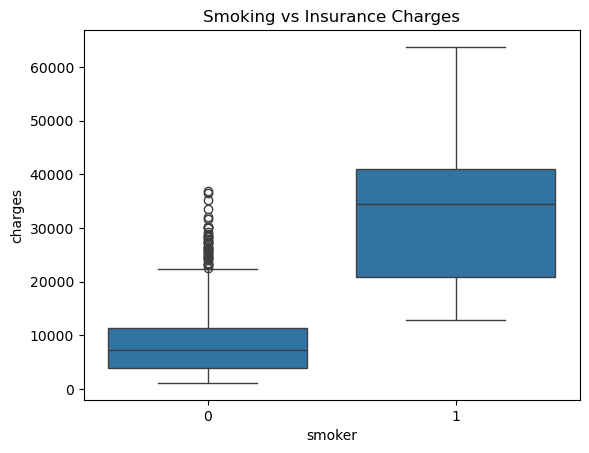

In [90]:
sns.boxplot(x='smoker', y='charges', data=df)

plt.title("Smoking vs Insurance Charges")

plt.savefig('D:\Internship\Task No 1\images\Task 4 img/Smoking_vs_Insurance.png')

In [91]:
X = df.drop('charges', axis=1)

y = df['charges']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [93]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
y_pred = model.predict(X_test)

In [95]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4186.508898366434


In [96]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 5799.587091438356
